# ML Benchmark and Inpainting Evaluation

Author: *Person 3*

This notebook compares classical inpainting methods (Telea, Navier-Stokes, Custom Propagation) against an ML-based method (LaMa). 
It evaluates the visual reconstruction quality (PSNR, SSIM) within the inpainted regions, and assesses the impact of reconstruction on an image classifier.

In [7]:
import sys
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from src.evaluation.metrics import evaluate
from src.evaluation.ml_inpaint import LaMaInpainter
try:
    from src.evaluation.classifier import PatchClassifierBenchmark
    has_ml = True
except ImportError:
    has_ml = False

from src.inpainting.inpaint_wrapper import InpaintWrapper

In [8]:
plt.rcParams['figure.figsize'] = (18, 6)

def plot_image_grid(images, titles, rows=1):
    cols = len(images) // rows
    fig, axes = plt.subplots(rows, cols)
    axes = axes.flatten() if rows * cols > 1 else [axes]
    
    for ax, img, title in zip(axes, images, titles):
        if len(img.shape) == 2:
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(img)
        ax.set_title(title, fontsize=14)
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

## Data Loading
We load a sample image from the generated dataset. We load the clean, patched, and mask image files.

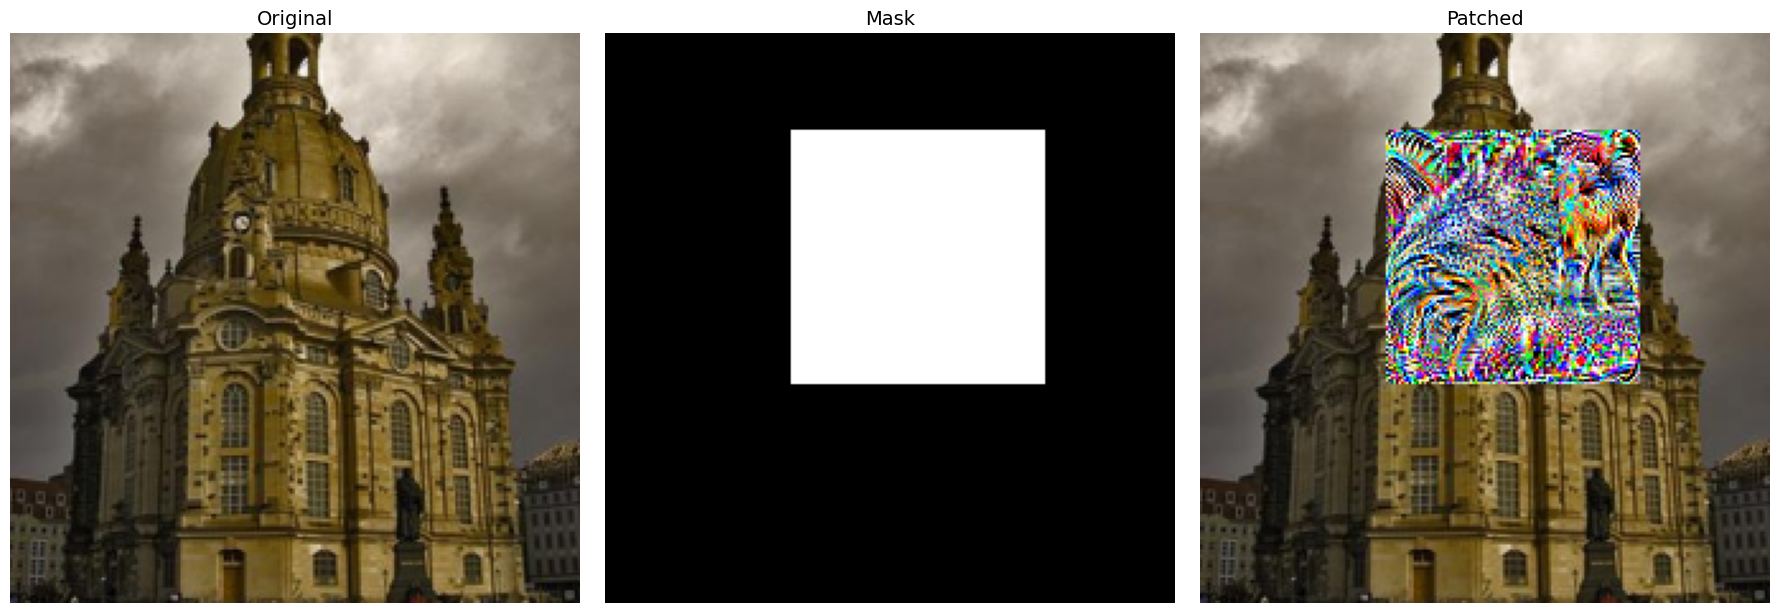

In [9]:
DIR_PATH = "../data/generated"
img_filename = "img0041.png"

if not os.path.exists(os.path.join(DIR_PATH, "clean", img_filename)):
    possible = os.listdir(os.path.join(DIR_PATH, "clean"))
    if possible:
        img_filename = possible[0]

clean_img = cv2.cvtColor(cv2.imread(os.path.join(DIR_PATH, "clean", img_filename)), cv2.COLOR_BGR2RGB)
mask_img = cv2.imread(os.path.join(DIR_PATH, "mask", img_filename), cv2.IMREAD_GRAYSCALE)
patched_img = cv2.cvtColor(cv2.imread(os.path.join(DIR_PATH, "patched", img_filename)), cv2.COLOR_BGR2RGB)

plot_image_grid([clean_img, mask_img, patched_img], ["Original", "Mask", "Patched"])

## Classical vs ML Inpainting

We apply:
1. `cv2.INPAINT_TELEA`
2. `cv2.INPAINT_NS`
3. Custom `propagation`
4. Pre-trained ML model `LaMa`

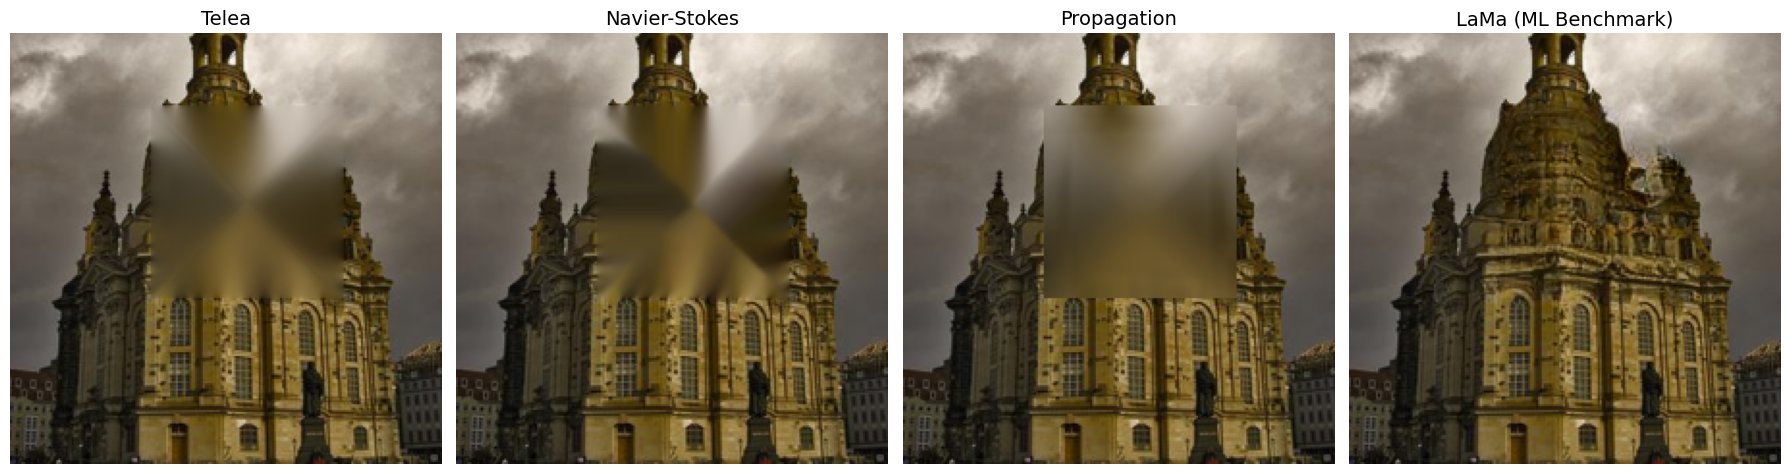

In [10]:
radius_val = 15

img_telea = InpaintWrapper.apply_inpaint(patched_img, mask_img, method="telea", radius=radius_val)
img_ns = InpaintWrapper.apply_inpaint(patched_img, mask_img, method="ns", radius=radius_val)
img_prop = InpaintWrapper.apply_inpaint(patched_img, mask_img, method="propagation", radius=radius_val)

if has_ml:
    lama = LaMaInpainter()
    img_lama = lama.inpaint(patched_img, mask_img)
else:
    img_lama = np.zeros_like(patched_img)

plot_image_grid(
    [img_telea, img_ns, img_prop, img_lama], 
    ["Telea", "Navier-Stokes", "Propagation", "LaMa (ML Benchmark)"], 
    rows=1
)

## Quantitative Evaluation (PSNR / SSIM)

We calculate PSNR and SSIM exclusively within the masked region using functions from `src.evaluation.metrics`.

In [11]:
metrics_telea = evaluate(img_telea, clean_img, mask_img)
metrics_ns = evaluate(img_ns, clean_img, mask_img)
metrics_prop = evaluate(img_prop, clean_img, mask_img)

if has_ml:
    metrics_lama = evaluate(img_lama, clean_img, mask_img)


## Classifier Benchmark

We want to observe how the adversarial patch impacts the prediction of an ImageNet classifier (ResNet50), and whether successful inpainting can recover the original class label (or at least provide a less aberrant prediction).

In [12]:
if has_ml:
    from collections import Counter
    from torchvision.models import ResNet50_Weights
    
    benchmark = PatchClassifierBenchmark()

    try:
        IMAGENET_CATEGORIES = ResNet50_Weights.DEFAULT.meta["categories"]
    except Exception:
        IMAGENET_CATEGORIES = None
    
    DIR_PATH = "../data/generated"
    clean_dir = os.path.join(DIR_PATH, "clean")

    if not os.path.exists(clean_dir):
        print(f"Dataset directory {clean_dir} not found. Run dataset generation first.")
    else:
        image_files = [f for f in os.listdir(clean_dir) if f.endswith(('.png', '.jpg'))]
        total_images = len(image_files)
        
        print(f"Evaluating {total_images} images from the dataset. This might take a minute...")
        
        methods = ['clean', 'patched', 'telea', 'ns', 'prop', 'lama']
        results = {m: {'acc': 0, 'preds': [], 'psnr': [], 'ssim': []} for m in methods}

        if 'lama' not in locals():
            lama = LaMaInpainter()
            
        for filename in image_files:
            clean_img = cv2.cvtColor(cv2.imread(os.path.join(DIR_PATH, "clean", filename)), cv2.COLOR_BGR2RGB)
            mask_img = cv2.imread(os.path.join(DIR_PATH, "mask", filename), cv2.IMREAD_GRAYSCALE)
            patched_img = cv2.cvtColor(cv2.imread(os.path.join(DIR_PATH, "patched", filename)), cv2.COLOR_BGR2RGB)
            
            # Predict baseline
            pred_clean = benchmark.predict(clean_img)
            pred_patched = benchmark.predict(patched_img)
            
            results['clean']['preds'].append(pred_clean)
            results['patched']['preds'].append(pred_patched)
            
            if pred_clean == pred_clean: results['clean']['acc'] += 1
            if pred_patched == pred_clean: results['patched']['acc'] += 1
            
            # Helper to load or compute inpainting
            def get_inpainted(method_name, folder_path, compute_fn):
                path = os.path.join(DIR_PATH, "inpainted", folder_path, filename)
                if os.path.exists(path):
                    return cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
                else:
                    return compute_fn()

            r_val = radius_val if 'radius_val' in locals() else 15
            
            img_t = get_inpainted("telea", f"telea/radius={r_val}", lambda: InpaintWrapper.apply_inpaint(patched_img, mask_img, method="telea", radius=r_val))
            img_n = get_inpainted("ns", f"ns/radius={r_val}", lambda: InpaintWrapper.apply_inpaint(patched_img, mask_img, method="ns", radius=r_val))
            img_p = get_inpainted("prop", f"propagation/radius={r_val}", lambda: InpaintWrapper.apply_inpaint(patched_img, mask_img, method="propagation", radius=r_val))
            img_l = get_inpainted("lama", "lama", lambda: lama.inpaint(patched_img, mask_img))
            
            eval_data = {
                'telea': img_t,
                'ns': img_n,
                'prop': img_p,
                'lama': img_l
            }
            
            for m_name, m_img in eval_data.items():
                pred = benchmark.predict(m_img)
                results[m_name]['preds'].append(pred)
                if pred == pred_clean:
                    results[m_name]['acc'] += 1
                    
                metrics = evaluate(pred=m_img, target=clean_img, mask=mask_img)
                results[m_name]['psnr'].append(metrics['psnr'])
                results[m_name]['ssim'].append(metrics['ssim'])
                
        def get_most_freq(preds):
            if not preds: return "N/A"
            most_common = Counter(preds).most_common(1)[0]
            cls_id = most_common[0]
            count = most_common[1]
            if IMAGENET_CATEGORIES and cls_id < len(IMAGENET_CATEGORIES):
                cls_name = IMAGENET_CATEGORIES[cls_id]
                return f"{cls_name} [{cls_id}] ({count} times)"
            return f"{cls_id} ({count} times)"

        print("\n--- Final Aggregate Evaluation ---")
        
        clean_acc = results['clean']['acc']
        print(f"[BASE CLEAN  ]                           | Class Acc (vs clean): {clean_acc}/{total_images} ({(clean_acc/total_images)*100:.1f}%) | Most Freq Missclasification: {get_most_freq(results['clean']['preds'])}")
        
        patched_acc = results['patched']['acc']
        print(f"[BASE PATCHED]                           | Class Acc (vs clean): {patched_acc}/{total_images} ({(patched_acc/total_images)*100:.1f}%)   | Most Freq Missclasification: {get_most_freq(results['patched']['preds'])}")
        
        for m_name, label in [('telea', 'TELEA'), ('ns', 'NAVIERSTOKES'), ('prop', 'PROPAGATION'), ('lama', 'LAMA (ML)')]:
            valid_psnr = [p for p in results[m_name]['psnr'] if p != float('inf')]
            avg_psnr = np.mean(valid_psnr) if valid_psnr else float('nan')
            avg_ssim = np.mean(results[m_name]['ssim'])
            acc = results[m_name]['acc']
            most_freq = get_most_freq(results[m_name]['preds'])
            
            print(f"[{label:<12}] PSNR: {avg_psnr:5.2f} | SSIM: {avg_ssim:5.3f} | Class Acc (vs clean): {acc}/{total_images} ({(acc/total_images)*100:.1f}%)   | Most Freq Missclasification: {most_freq}")
else:
    print("PyTorch and torchvision not installed. Skipping benchmark.")


Evaluating 100 images from the dataset. This might take a minute...

--- Final Aggregate Evaluation ---
[BASE CLEAN  ]                           | Class Acc (vs clean): 100/100 (100.0%) | Most Freq Missclasification: French horn [566] (14 times)
[BASE PATCHED]                           | Class Acc (vs clean): 15/100 (15.0%)   | Most Freq Missclasification: zebra [340] (85 times)
[TELEA       ] PSNR: 13.56 | SSIM: 0.304 | Class Acc (vs clean): 74/100 (74.0%)   | Most Freq Missclasification: French horn [566] (12 times)
[NAVIERSTOKES] PSNR: 13.45 | SSIM: 0.307 | Class Acc (vs clean): 73/100 (73.0%)   | Most Freq Missclasification: French horn [566] (12 times)
[PROPAGATION ] PSNR: 13.31 | SSIM: 0.276 | Class Acc (vs clean): 77/100 (77.0%)   | Most Freq Missclasification: French horn [566] (12 times)
[LAMA (ML)   ] PSNR: 14.88 | SSIM: 0.365 | Class Acc (vs clean): 82/100 (82.0%)   | Most Freq Missclasification: French horn [566] (13 times)
